# Improving YOLO by preprocessing

In [14]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Loading the model
model = YOLO('C:/Users/user/runs/detect/run200imgsAnd100epochs2/weights/best.pt')

# Loading image
img_path =r"C:\Users\user\Desktop\iaa-pictures\OriginalWhatsApp Image 2025-07-13 at 11.00.52_975f6140.jpg"
img = cv2.imread(img_path)

### Running the model without preprocessing


0: 480x640 3 shards, 211.3ms
Speed: 6.6ms preprocess, 211.3ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


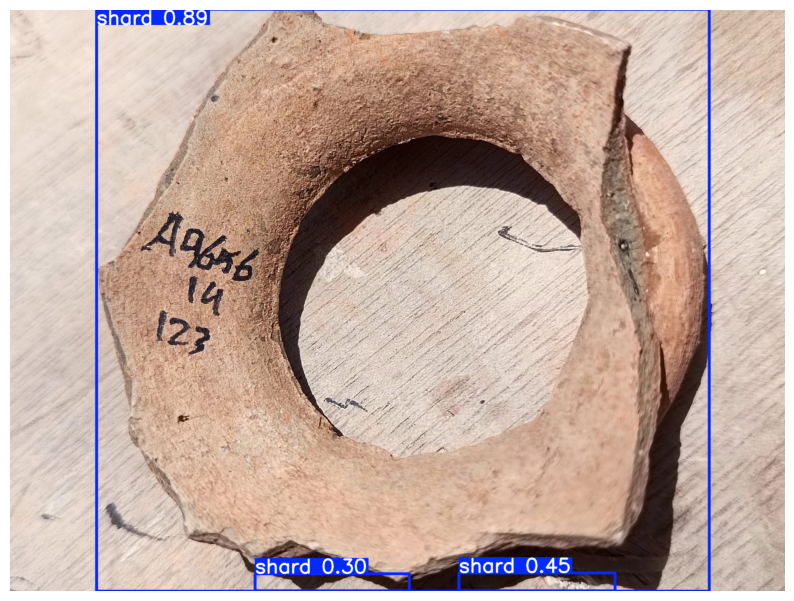

In [45]:


# Running Yolo
results = model(img)

# Displaying the result with bounding boxes
for r in results:
    annotated_frame = r.plot() 
    
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(annotated_frame)
plt.axis("off")
plt.show()

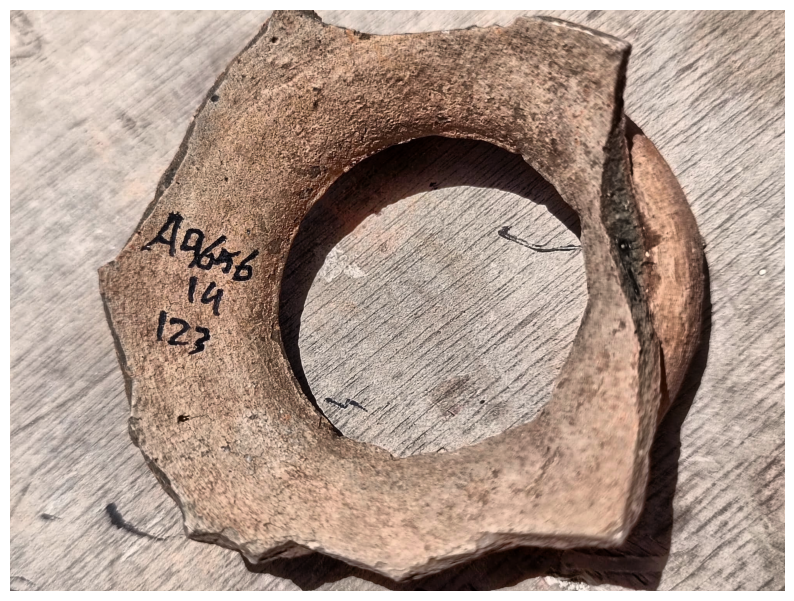

In [46]:

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


v = hsv[:,:,2]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
v_eq = clahe.apply(v)

hsv[:,:,2] = v_eq
img_eq = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img_eq)
plt.axis("off")
plt.show()



0: 480x640 1 shard, 228.1ms
Speed: 6.1ms preprocess, 228.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


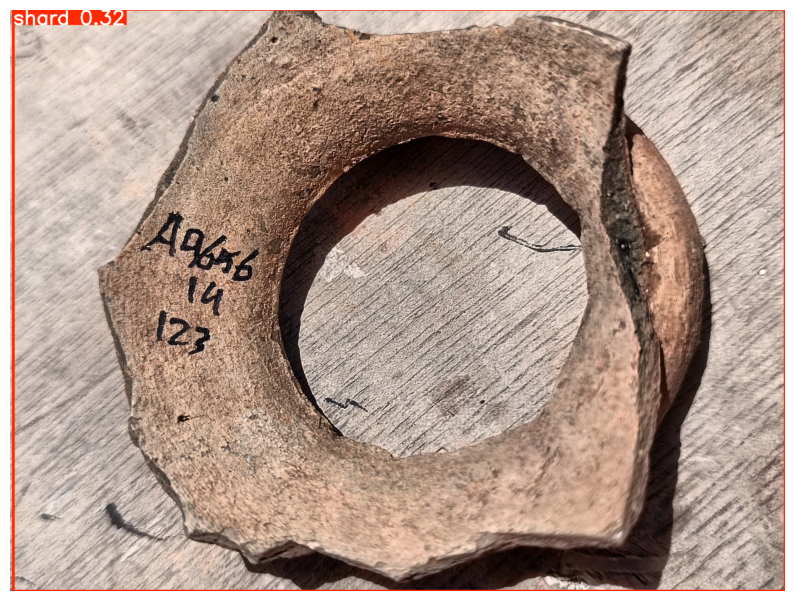

In [47]:
# Running Yolo
results = model(img_eq)

# Displaying the result with bounding boxes
for r in results:
    annotated_frame = r.plot() 
    


plt.figure(figsize=(10,10))
plt.imshow(annotated_frame)
plt.axis("off")
plt.show()

## Performance evaluation on various preprocessing-the whole picture

In [48]:
import os


input_dir = r"C:\Users\user\Desktop\project_folder\images\test"
output_dir = r"C:\Users\user\Desktop\project_folder\datasets_preprocessed\images"
os.makedirs(output_dir, exist_ok=True)

def preprocess(img):
   
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    hsv[:,:,2] = clahe.apply(v)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

for fname in os.listdir(input_dir):
    if fname.lower().endswith((".jpg", ".png")):
        img = cv2.imread(os.path.join(input_dir, fname))
        img_out = preprocess(img)
        cv2.imwrite(os.path.join(output_dir, fname), img_out)


In [49]:
from ultralytics import YOLO

model = YOLO('runs/detect/run200imgsAnd100epochs2/weights/best.pt')
metrics = model.val(data=r"C:\Users\user\Desktop\project_folder\data_preprocessed.yaml", split='test')


Ultralytics 8.3.163  Python-3.11.3 torch-2.7.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 50.425.5 MB/s, size: 875.2 KB)


val: Scanning C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels... 28 images, 0 backgrounds, 0 corrupt:

val: New cache created: C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels.cache



C:\Users\user\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<0


                   all         28        315      0.955      0.924      0.949      0.812
Speed: 2.5ms preprocess, 100.9ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs\detect\val26


In [50]:
import shutil, os

folder = r"C:/Users/user/Desktop/project_folder/datasets_preprocessed/images"
for f in os.listdir(folder):
    path = os.path.join(folder, f)
    shutil.rmtree(path) if os.path.isdir(path) else os.unlink(path)


In [51]:
def denoise(img, h=10):
    return cv2.fastNlMeansDenoisingColored(img, None, h, h, 7, 21)


In [52]:

for fname in os.listdir(input_dir):
    if fname.lower().endswith((".jpg", ".png")):
        img = cv2.imread(os.path.join(input_dir, fname))
        img_out = denoise(img)
        cv2.imwrite(os.path.join(output_dir, fname), img_out)


In [15]:
metrics = model.val(data=r"C:\Users\user\Desktop\project_folder\data_preprocessed.yaml", split='test')

Ultralytics 8.3.163  Python-3.11.3 torch-2.7.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
val: Fast image access  (ping: 0.30.2 ms, read: 29.619.0 MB/s, size: 577.5 KB)


val: Scanning C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels... 28 images, 0 backgrounds, 0 corrupt:

val: New cache created: C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels.cache



C:\Users\user\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<0


                   all         28        315       0.95       0.94      0.954      0.821
Speed: 1.6ms preprocess, 115.1ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs\detect\val24


In [59]:
import shutil, os

folder = r"C:/Users/user/Desktop/project_folder/datasets_preprocessed/images"
for f in os.listdir(folder):
    path = os.path.join(folder, f)
    shutil.rmtree(path) if os.path.isdir(path) else os.unlink(path)


In [60]:
def gaussian_blur(img, ksize=(3,3)):
    return cv2.GaussianBlur(img, ksize, 0)


In [61]:
for fname in os.listdir(input_dir):
    if fname.lower().endswith((".jpg", ".png")):
        img = cv2.imread(os.path.join(input_dir, fname))
        img_out = gaussian_blur(img)
        cv2.imwrite(os.path.join(output_dir, fname), img_out)


In [62]:
metrics = model.val(data=r"C:\Users\user\Desktop\project_folder\data_preprocessed.yaml", split='test')

Ultralytics 8.3.163  Python-3.11.3 torch-2.7.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
val: Fast image access  (ping: 0.10.0 ms, read: 72.640.2 MB/s, size: 604.5 KB)


val: Scanning C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels.cache... 28 images, 0 backgrounds, 0 co
C:\Users\user\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<0


                   all         28        315      0.943      0.945      0.956       0.83
Speed: 2.9ms preprocess, 97.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs\detect\val29


In [66]:
import shutil, os

folder = r"C:/Users/user/Desktop/project_folder/datasets_preprocessed/images"
for f in os.listdir(folder):
    path = os.path.join(folder, f)
    shutil.rmtree(path) if os.path.isdir(path) else os.unlink(path)


In [67]:
def adjust_gamma(img, gamma=1.1):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)


In [69]:
import numpy as np

for fname in os.listdir(input_dir):
    if fname.lower().endswith((".jpg", ".png")):
        img = cv2.imread(os.path.join(input_dir, fname))
        img_out = adjust_gamma(img)
        cv2.imwrite(os.path.join(output_dir, fname), img_out)


In [70]:
metrics = model.val(data=r"C:\Users\user\Desktop\project_folder\data_preprocessed.yaml", split='test')

Ultralytics 8.3.163  Python-3.11.3 torch-2.7.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
val: Fast image access  (ping: 0.10.0 ms, read: 79.156.3 MB/s, size: 717.9 KB)


val: Scanning C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels... 28 images, 0 backgrounds, 0 corrupt:

val: New cache created: C:\Users\user\Desktop\project_folder\datasets_preprocessed\labels.cache



C:\Users\user\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:04<0


                   all         28        315      0.949      0.943      0.954      0.824
Speed: 3.4ms preprocess, 101.6ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs\detect\val30


In [1]:
import shutil, os

folder = r"C:/Users/user/Desktop/project_folder/datasets_preprocessed/images"
for f in os.listdir(folder):
    path = os.path.join(folder, f)
    shutil.rmtree(path) if os.path.isdir(path) else os.unlink(path)


## Processing on dark areas only

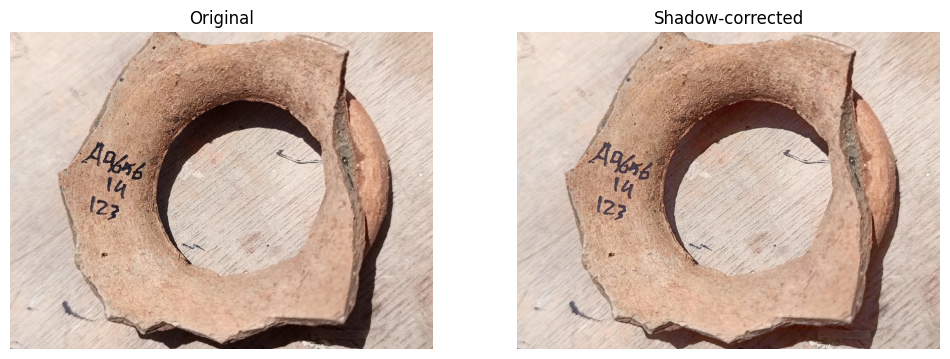

In [16]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

mask_shadow = v < 60
v[mask_shadow] = np.clip(v[mask_shadow] + 40, 0, 255)


final = cv2.merge([h, s, v])
bright = cv2.cvtColor(final, cv2.COLOR_HSV2BGR)
bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)

orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bright_rgb)
plt.title("Shadow-corrected")
plt.axis("off")

plt.show()



0: 480x640 3 shards, 252.6ms
Speed: 10.0ms preprocess, 252.6ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)


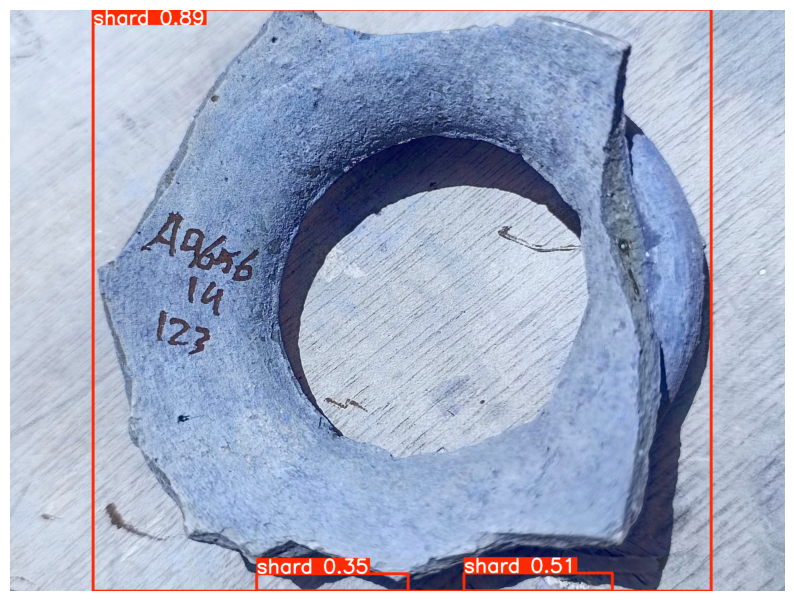

In [23]:
model = YOLO(r"C:/Users/user/runs/detect/run200imgsAnd100epochs2/weights/best.pt")
results = model(bright)

plt.figure(figsize=(10,10))
plt.imshow(results[0].plot())
plt.axis("off")
plt.show()


0: 480x640 3 shards, 247.2ms
Speed: 12.7ms preprocess, 247.2ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)


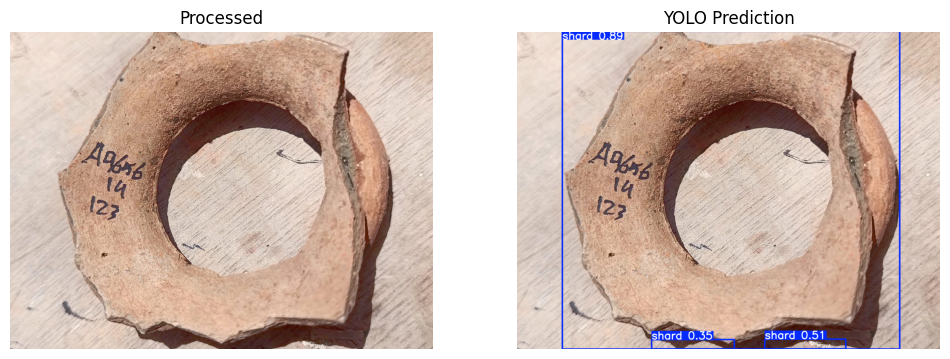

In [24]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"C:/Users/user/runs/detect/run200imgsAnd100epochs2/weights/best.pt")
bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)

results = model(bright)
yolo_img = results[0].plot()  

yolo_rgb = cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(bright_rgb)
plt.title("Processed")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(yolo_rgb)
plt.title("YOLO Prediction")
plt.axis("off")

plt.show()


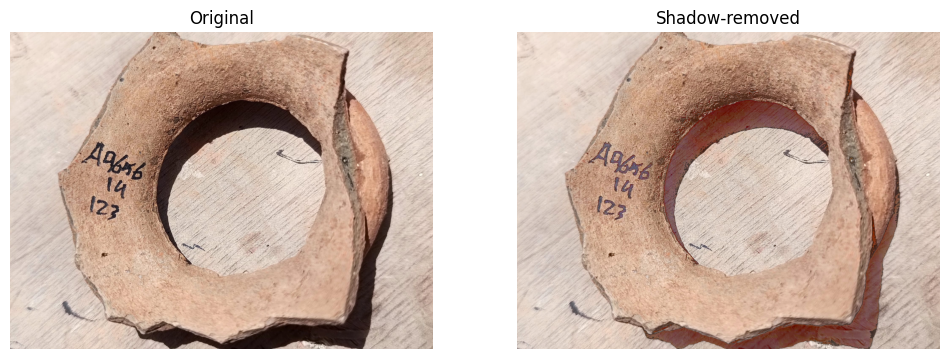

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_shadows(img, brightness_increase=80, v_thresh=60, show_result=True):
    """
    מחיקת הצללים בתמונה על ידי זיהוי אזורים כהים והעלאת הבהירות שלהם.
    
    פרמטרים:
    img                - תמונה ב-BGR (cv2.imread)
    brightness_increase- כמה להעלות את הבהירות של הצללים
    v_thresh           - סף לזיהוי פיקסלים כהים (0-255)
    show_result        - אם True, מציג את המקור והמעובד לצד
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    mask_shadow = v < v_thresh
    
    v[mask_shadow] = np.clip(v[mask_shadow] + brightness_increase, 0, 255)
    
    final = cv2.merge([h, s, v])
    bright = cv2.cvtColor(final, cv2.COLOR_HSV2BGR)
    
    if show_result:
        orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12,6))
        plt.subplot(1,2,1)
        plt.imshow(orig_rgb)
        plt.title("Original")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(bright_rgb)
        plt.title("Shadow-removed")
        plt.axis("off")
        plt.show()
    
    return bright


bright = remove_shadows(img)



0: 480x640 4 shards, 253.3ms
Speed: 8.2ms preprocess, 253.3ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)


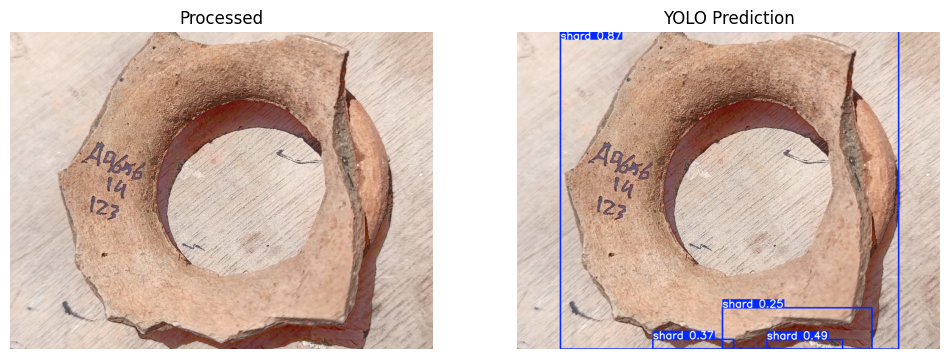

In [32]:




bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)


results = model(bright)
yolo_img = results[0].plot() 

yolo_rgb = cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(bright_rgb)
plt.title("Processed")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(yolo_rgb)
plt.title("YOLO Prediction")
plt.axis("off")

plt.show()


In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_shadows_smart(img, brightness_increase=80, v_thresh=60, s_thresh=60, show_result=True):
    """
    הסרת צללים בתמונה באופן חכם:
    - מזהה אזורים כהים רציפים (צללים) לפי ערך V + S
    - מעלה את הבהירות של הצללים (אפשר גם 'מחיקה' מוחלטת)
    - משאיר את האזורים הבהירים ללא שינוי
    - מציג את המקור והמעובד לצד
    
    פרמטרים:
    img                - תמונה ב-BGR (cv2.imread)
    brightness_increase- כמה להעלות את הבהירות של הצללים
    v_thresh           - סף לזיהוי פיקסלים כהים (0-255)
    s_thresh           - סף רוויה לזיהוי צללים (0-255)
    show_result        - אם True, מציג את המקור והמעובד
    """
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
 
    mask_shadow = (v < v_thresh) & (s > s_thresh)
    
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask_shadow = cv2.morphologyEx(mask_shadow.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    
   
    v[mask_shadow.astype(bool)] = 255 

    
    final = cv2.merge([h, s, v])
    bright = cv2.cvtColor(final, cv2.COLOR_HSV2BGR)
    
    if show_result:
        orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12,6))
        plt.subplot(1,2,1)
        plt.imshow(orig_rgb)
        plt.title("Original")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(bright_rgb)
        plt.title("Shadow-removed")
        plt.axis("off")
        plt.show()
    
    return bright



bright = remove_shadows_smart(img)
